In [126]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [116]:
df = pd.read_csv("../data/raw/tokyo_stations.csv")

print(df.head())

   name prefecture   line           x          y   postal  prev  next
0    東京        東京都  JR中央線  139.766103  35.681391  1000005   NaN    神田
1    神田        東京都  JR中央線  139.770641  35.691173  1010044    東京  御茶ノ水
2  御茶ノ水        東京都  JR中央線  139.764955  35.699604  1010062    神田   水道橋
3   水道橋        東京都  JR中央線  139.754312  35.702039  1010061  御茶ノ水   飯田橋
4   飯田橋        東京都  JR中央線  139.745143  35.701835  1020072   水道橋   市ケ谷


# Build a graph

In [117]:
G = nx.MultiDiGraph()

In [118]:
# Create Node
for _, row in df.iterrows():
    station = row["name"]
    station_x = row["x"]
    station_y = row["y"]

    
    if station in G:
        pass
    else:
        G.add_node(
            station,
            x = station_x,
            y = station_y
        )

# Create Edge
for _, row in df.iterrows():
    station = row["name"]
    next_station = row["next"]
    
    if pd.notna(next_station):
        station_line = row["line"]
        G.add_edge(station, next_station, line = station_line)

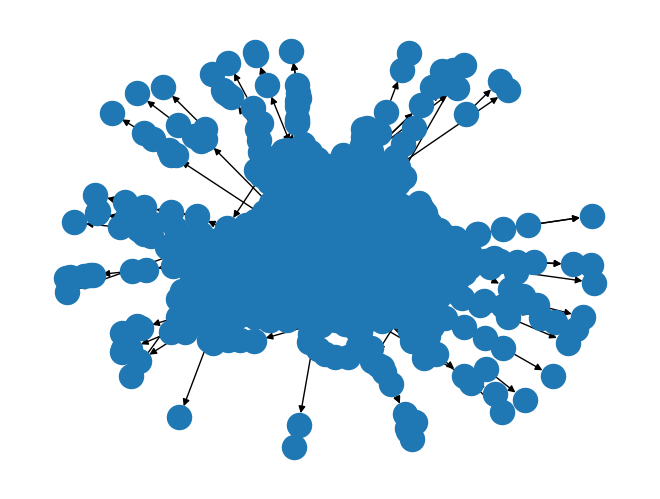

In [119]:
nx.draw(G)

In [120]:
centrality = nx.betweenness_centrality(
    G,
    normalized=True,
    weight=None
)


top20 = sorted(
    centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

for station, score in top20:
    print(f"{station}: {score:.4f}")

上野: 0.1628
品川: 0.1606
東京: 0.1320
小川町: 0.1248
池袋: 0.1175
大宮: 0.1141
錦糸町: 0.1131
新宿: 0.1129
北千住: 0.1107
菊川: 0.1105
森下: 0.1065
住吉: 0.1058
押上: 0.1053
東飯能: 0.1035
明覚: 0.1029
越生: 0.1026
毛呂: 0.1023
高麗川: 0.1020
赤羽: 0.1016
拝島: 0.0971


In [149]:
pos = {
    node: (attrs["x"], attrs["y"])
    for node, attrs in G.nodes(data=True)
}

# sizes = [
#     5 + 500*np.sqrt(centrality[node])
#     for node in G.nodes()
# ]

# plt.figure(figsize=(80, 80))
# nx.draw(
#     G,
#     pos,
#     node_size=sizes,
#     arrows=False,
#     with_labels=False
# )

colors = [centrality[node] for node in G.nodes()]

plt.figure(figsize=(80,80))

nx.draw(
    G,
    pos,
    node_size=50,
    node_color=colors,
    cmap="viridis",
    with_labels=False,
    width=0.5
)

plt.savefig(
    "../imgs/tokyo_network.pdf",
    format="pdf",
    bbox_inches="tight"
)